# 07 — Splitting the connection-scaling coefficient by consumer class

**What this notebook is.** Notebook 06 (the ICP regression) established that the
2013–2025 deepening of overnight leading reactive power scales with the number of
connections served: −230 VAr per connection. This notebook asks *which connections
carry it*. The registry classifies every connection by ANZSIC industry code
(residential connections carry none; divisions A–E are industrial, F–Z commercial),
published per root NSP — the same key the panel's counts already join on. Splitting
the count into residential and commercial-industrial (C&I) parts and fitting one
coefficient to each discriminates between the two live mechanisms:

- **device fleet** (EMC-filter capacitance in mains-connected products) — lives
  behind *every* connection, ~86% of which are residential;
- **stranded power-factor correction** (banks installed against peak lagging
  demand, left in overnight where control is fixed or coarsely stepped) — can only
  live behind C&I connections.

**Bottom line (three findings):**

1. **The residential class carries the smaller coefficient, and it is the class
   that cannot hold correction plant.** −147 VAr per connection (95% CI
   [−240,−81] resampling units, [−329,−86] whole companies), measured on the 86%
   of connections that hold no correction plant at all. ⚠ This is a twelve-year
   *change*, NOT the standing *level* the bottom-up 100–200 VAr per-household
   estimate predicts — the level is the matched-vintage series below, which reads
   −310 VAr per residential connection in 2025. Do not compare the two. **[V]**
2. **The C&I coefficient is bounded well below the stranded-correction threat.**
   −915 [−1392,−299]: larger per connection, as commercial device fleets and shared
   cable predict, but far below the ~2 kVAr per connection that an average stranded
   bank would read. The two counts are collinear (r = 0.94), so the split is bounds,
   not a sharp allocation. **[V for the bound]**
3. **As a class, C&I connections have not yet crossed.** The yearly matched level
   split shows the C&I standing level descending from ~+0.9 kVAr per connection
   (net lagging) in 2018 toward zero by 2025, its interval always spanning zero,
   while the residential level is leading in every year and deepening. A class
   whose standing overnight position is still net lagging is not a class dominated
   by stranded correction capacitors. **[I]**

**Provenance is part of the result.** The registry file
(`MeterCategoryByLevel1ANZSIC.csv`) is published as a rolling snapshot — the EMI
dataset store holds only the latest month. The history used here was recovered from
the **Internet Archive's Wayback Machine**: 25 date-stamped snapshots, December
2018 – October 2025, plus the live July 2026 file. A logged CDX search found no
earlier vintage anywhere, so class-resolved history begins December 2018 and the
2021 year-end is missing (no capture exists between Dec 2020 and Dec 2022).

In [1]:
import json
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _cand in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_cand / "repro.py").exists():
        sys.path.insert(0, str(_cand))
        break
import repro

repro.set_style()
RNG = np.random.default_rng(20260822)

PAPER = repro.REPLICATION.parent / "ieee-pf-trajectory-paper"
REG = PAPER / "icp-regression"
RAW = REG / "data_raw"

VINTAGES = sorted(p.name.split("_")[0] for p in RAW.glob("*_MeterCategoryByLevel1ANZSIC.csv.gz"))
YEARENDS = ["20181231", "20191231", "20201231", "20221231", "20231031", "20241231",
            "20251031", "20260731"]
YMAP = {2018: "20181231", 2019: "20191231", 2020: "20201231", 2022: "20221231",
        2023: "20231031", 2024: "20241231", 2025: "20251031"}
print(f"{len(VINTAGES)} vintages on disk, {VINTAGES[0]} … {VINTAGES[-1]}")
assert len(VINTAGES) == 26, "expected 26 archived vintages (25 Wayback + 1 live)"

26 vintages on disk, 20181231 … 20260731


## Load, classify, join

Each vintage is Root NSP × ANZSIC L1 × meter category. We take the first seven
characters of the root NSP as the point of connection, classify rows into
residential (ANZSIC `0`/`000` — the EA's own convention: residential means *no*
industry code) versus C&I (everything else), and map connection points into the
paper's 96 panel units with the same correspondence-audit aggregation used by
notebook 06. Meter categories 3–5 (current-transformer and high-voltage metering)
are kept as the *bank-capable* population — the sites physically able to hold a
power-factor-correction bank of consequence; category 2 (LV CT, 100–500 A) is kept
as the small-bank margin.

In [2]:
res_json = json.load(open(REG / "icp_regression_results_20260806.json"))
agg = res_json["panel_rebase_20260808"]["aggregation_units"]
panel = pd.read_csv(REG / "panel_96_with_company.csv")
p2u = {m: u for u in panel.site for m in agg.get(u, [u])}

def load_vintage(stamp):
    d = pd.read_csv(RAW / f"{stamp}_MeterCategoryByLevel1ANZSIC.csv.gz", dtype=str)
    d.columns = [c.strip() for c in d.columns]
    assert "Root NSP" in d.columns and "ANZSIC L1" in d.columns, f"{stamp}: schema break"
    d["poc"] = d["Root NSP"].str.strip().str[:7]
    d["anz"] = d["ANZSIC L1"].astype(str).str.strip()
    for c in ["ICP count (total)", "Cat2", "Cat3", "Cat4", "Cat5"]:
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0)
    d["cls"] = np.where(d.anz.isin({"0", "000"}), "res", "ci")
    d["unit"] = d.poc.map(p2u)
    du = d.dropna(subset=["unit"])
    u = du.groupby(["unit", "cls"])["ICP count (total)"].sum().unstack(fill_value=0)
    u["cat2"] = du.groupby("unit").Cat2.sum()
    u["cat345"] = du.groupby("unit")[["Cat3", "Cat4", "Cat5"]].sum().sum(axis=1)
    return u, float(d["ICP count (total)"].sum())

frames, national = {}, {}
for v in VINTAGES:
    frames[v], national[v] = load_vintage(v)
    assert len(frames[v]) == 96, f"{v}: joined {len(frames[v])} of 96 units"
    assert 2.0e6 < national[v] < 2.5e6, f"{v}: national total {national[v]:,.0f} implausible"
print("join: 96/96 panel units in every one of the 26 vintages")
print(f"national ICP totals: {national[VINTAGES[0]]:,.0f} (Dec 2018) → "
      f"{national[VINTAGES[-1]]:,.0f} (Jul 2026)")

join: 96/96 panel units in every one of the 26 vintages
national ICP totals: 2,134,398 (Dec 2018) → 2,368,870 (Jul 2026)


**One registry artefact to know about before reading trends:** between the
February and March 2020 snapshots the C&I share of panel connections steps from
0.138 to 0.144 — roughly fifteen thousand connections re-coded in one month, a
registry reclassification batch, not physics. The class *mix* is otherwise flat
across the whole vintage record (0.138–0.144), which is itself a finding: the
composition of connection growth did not tilt commercial.

In [3]:
mixseries = pd.DataFrame({v: {"res": frames[v].res.sum(), "ci": frames[v].ci.sum(),
                              "cat2": frames[v].cat2.sum(), "cat345": frames[v].cat345.sum()}
                          for v in VINTAGES}).T
mixseries["total"] = mixseries.res + mixseries.ci
mixseries["s_ci"] = mixseries.ci / mixseries.total
assert mixseries.s_ci.between(0.13, 0.15).all(), "class mix left its historical band"
step = mixseries.loc["20200331", "s_ci"] - mixseries.loc["20200229", "s_ci"]
print(f"class mix s_ci: min {mixseries.s_ci.min():.3f}, max {mixseries.s_ci.max():.3f} "
      f"(Mar-2020 recode step {step:+.4f})")
print(mixseries.loc[YEARENDS].round(3).to_string())

class mix s_ci: min 0.137, max 0.145 (Mar-2020 recode step +0.0062)
              res      ci   cat2  cat345    total   s_ci
20181231  1269150  204057  17312    3317  1473207  0.139
20191231  1293627  206499  17555    3413  1500126  0.138
20201231  1317026  222110  18008    3553  1539136  0.144
20221231  1353874  228651  18543    3755  1582525  0.144
20231031  1379852  224844  18824    3913  1604696  0.140
20241231  1407710  225996  19119    4060  1633706  0.138
20251031  1416095  230324  19444    4146  1646419  0.140
20260731  1428530  229353  19578    4196  1657883  0.138


## The change split — which class carries the −230?

Design: notebook 06's regression, with the single count split in two. The class
counts are the **vintage-mean** over the eight year-marks (the honest average of
what the registry actually recorded), rescaled onto each unit's 2013–2025 mean
count so the pooled basis matches the paper's headline fit; single-snapshot
vintages (2018-only, 2026-only) are run as sensitivities. Everything is resampled
two ways, 4,000 replicates: units independently, and whole companies (sites under
one owner are not independent).

In [4]:
mean_counts = sum(frames[v][["res", "ci"]] for v in YEARENDS) / len(YEARENDS)
m = panel.set_index("site").join(mean_counts)
scale = m.Nbar / (m.res + m.ci)
m["N_res"], m["N_ci"] = m.res * scale, m.ci * scale

def fit(y, X):
    A = np.column_stack([np.ones(len(y))] + X)
    return np.linalg.lstsq(A, y, rcond=None)[0]

def boot(y, X, comp, cluster, n=4000):
    idx = np.arange(len(y)); uniq = np.unique(comp); es = []
    for _ in range(n):
        take = (np.concatenate([idx[comp == c] for c in RNG.choice(uniq, len(uniq), True)])
                if cluster else RNG.choice(idx, len(idx), True))
        try:
            es.append(fit(y[take], [x[take] for x in X]))
        except np.linalg.LinAlgError:
            pass
    return np.percentile(es, [2.5, 97.5], axis=0)

y = m.dQ.values  # stored positive = deepening; the paper prints these negative
X = [m.N_res.values, m.N_ci.values]
b_pool = fit(y, [m.Nbar.values])
assert abs(b_pool[1] * 1e6 - 230) < 5, "pooled slope no longer reproduces the paper"
b = fit(y, X)
cu = boot(y, X, m.company.values, False)
cc = boot(y, X, m.company.values, True)
collin = float(np.corrcoef(m.N_res, m.N_ci)[0, 1])
print(f"pooled reproduction: {b_pool[1]*1e6:.0f} VAr/conn (paper: 230)")
print(f"residential {b[1]*1e6:+.0f}  [{cu[0,1]*1e6:+.0f},{cu[1,1]*1e6:+.0f}] units, "
      f"[{cc[0,1]*1e6:+.0f},{cc[1,1]*1e6:+.0f}] companies")
print(f"C&I         {b[2]*1e6:+.0f}  [{cu[0,2]*1e6:+.0f},{cu[1,2]*1e6:+.0f}] units, "
      f"[{cc[0,2]*1e6:+.0f},{cc[1,2]*1e6:+.0f}] companies")
print(f"collinearity corr(N_res, N_ci) = {collin:.3f} — the split is bounds, not allocation")
assert cu[1, 1] * 1e6 < 0 or cu[0, 1] * 1e6 > 0, "residential CI must exclude zero"
assert cu[1, 2] * 1e6 < 2000, "C&I upper bound crossed the 2 kVAr threat line"

sens = {}
for label, vv in [("2018 shares", "20181231"), ("2026 shares", "20260731")]:
    mm = panel.set_index("site").join(frames[vv][["res", "ci"]])
    sc = mm.Nbar / (mm.res + mm.ci)
    bs = fit(mm.dQ.values, [(mm.res * sc).values, (mm.ci * sc).values])
    sens[label] = (bs[1] * 1e6, bs[2] * 1e6)
    print(f"sensitivity {label}: res {bs[1]*1e6:+.0f}, C&I {bs[2]*1e6:+.0f}")

pooled reproduction: 230 VAr/conn (paper: 230)
residential +147  [+81,+240] units, [+86,+329] companies
C&I         +915  [+299,+1392] units, [+98,+1288] companies
collinearity corr(N_res, N_ci) = 0.937 — the split is bounds, not allocation
sensitivity 2018 shares: res +135, C&I +1011
sensitivity 2026 shares: res +158, C&I +853


## The concentration test — is the deepening where the C&I connections are?

If stranded correction carried the slope, units with more C&I connections should
deepen faster *per connection*. They do not: the per-connection rate is
statistically flat across the C&I-share gradient, and the tercile pooled rates
are indistinguishable. (Industrial-weighted sites in fact deepen *less* than
their counts predict — notebook 06's residual pattern.)

In [5]:
m26 = panel.set_index("site").join(frames["20260731"][["res", "ci"]])
m26["s_ci"] = m26.ci / (m26.res + m26.ci)
m26["rate"] = m26.dQ / m26.Nbar * 1e6
w = m26.Nbar.values
A = np.column_stack([np.ones(len(m26)), m26.s_ci.values])
bw = np.linalg.lstsq(A * np.sqrt(w)[:, None], m26.rate.values * np.sqrt(w), rcond=None)[0]
terc = m26.groupby(pd.qcut(m26.s_ci, 3, labels=["res-heavy", "mid", "C&I-heavy"]),
                   observed=True).apply(lambda t: t.dQ.sum() / t.Nbar.sum() * 1e6,
                                        include_groups=False)
print(f"weighted rate ~ share_ci slope: {bw[1]:+.0f} VAr/conn per unit share (≈ flat)")
print("tercile pooled rates:", terc.round(0).to_dict())

weighted rate ~ share_ci slope: +122 VAr/conn per unit share (≈ flat)
tercile pooled rates: {'res-heavy': 233.0, 'mid': 280.0, 'C&I-heavy': 228.0}


## The yearly matched level split — the standing position of each class

For every year with both a metered overnight record and a registry vintage
(2018–2025 except 2021), fit the standing overnight level on that year's *actual*
class counts. This is Fig. 6(B)'s coefficient history, split by class — and it is
where the two classes come apart: residential leading and deepening in every
year; C&I descending from net lagging toward zero and not yet across.

In [6]:
pnl = pd.read_parquet(repro.CACHE / "gxp_year_panel.parquet")
pnl["unit"] = pnl.gxp.map(p2u)
lv = pnl.dropna(subset=["unit"]).groupby(["unit", "year"]).on_Q.sum().unstack()

hist = {}
for yr, v in YMAP.items():
    u = frames[v][["res", "ci"]].join(lv[yr].rename("Q"), how="inner").dropna()
    assert len(u) == 96, f"{yr}: level rows {len(u)}"
    bb = fit(u.Q.values, [u.res.values, u.ci.values])
    ciy = boot(u.Q.values, [u.res.values, u.ci.values], np.arange(96), False)
    hist[yr] = dict(res=bb[1] * 1e6, res_lo=ciy[0, 1] * 1e6, res_hi=ciy[1, 1] * 1e6,
                    ci=bb[2] * 1e6, ci_lo=ciy[0, 2] * 1e6, ci_hi=ciy[1, 2] * 1e6)
    print(f"{yr}: res {bb[1]*1e6:+7.0f} [{ciy[0,1]*1e6:+.0f},{ciy[1,1]*1e6:+.0f}]   "
          f"C&I {bb[2]*1e6:+8.0f} [{ciy[0,2]*1e6:+.0f},{ciy[1,2]*1e6:+.0f}]")
H = pd.DataFrame(hist).T
assert (H.res_hi < 0).all(), "residential level CI must be clear of zero every year"
assert (H.ci > 0).all() and (H.ci_lo < 0).all(), \
    "C&I level: point lagging, interval spanning zero, every matched year"

2018: res    -247 [-401,-87]   C&I     +858 [-583,+2006]
2019: res    -283 [-426,-134]   C&I     +992 [-403,+2072]


2020: res    -283 [-408,-159]   C&I     +640 [-591,+1532]
2022: res    -320 [-471,-190]   C&I     +551 [-609,+1503]


2023: res    -302 [-435,-187]   C&I     +409 [-654,+1288]
2024: res    -306 [-441,-198]   C&I     +264 [-823,+1192]


2025: res    -310 [-435,-197]   C&I     +111 [-979,+1009]


## Growth composition — the change-not-level defence, on the full series

Correction plant loads the *level*; only growth in the stranded stock can load the
*change*. The populations able to carry it barely moved: connection growth on the
panel footprint is 86% residential; the C&I share of connections is flat; the
bank-capable population grew by ~3,100 sites — 1.7% of the connection growth.

In [7]:
g0, g1 = frames["20181231"], frames["20260731"]
dtot = (g1.res + g1.ci - g0.res - g0.ci).sum()
dres = (g1.res - g0.res).sum()
dcat = (g1.cat2 + g1.cat345 - g0.cat2 - g0.cat345).sum()
growth = dict(total=float(dtot), res=float(dres), res_share=float(dres / dtot),
              cat345_2018=float(g0.cat345.sum()), cat345_2026=float(g1.cat345.sum()),
              cat2_2018=float(g0.cat2.sum()), cat2_2026=float(g1.cat2.sum()),
              ct_growth=float(dcat), ct_share_of_growth=float(dcat / dtot))
print(f"connection growth Dec 2018 → Jul 2026: {dtot:+,.0f}, residential {dres/dtot:.1%}")
print(f"CT-metered (bank-capable) sites: Cat3–5 {g0.cat345.sum():,.0f} → {g1.cat345.sum():,.0f}, "
      f"Cat2 {g0.cat2.sum():,.0f} → {g1.cat2.sum():,.0f}; together {dcat:+,.0f} "
      f"= {dcat/dtot:.1%} of connection growth")
assert growth["res_share"] > 0.8 and growth["ct_share_of_growth"] < 0.05

connection growth Dec 2018 → Jul 2026: +184,676, residential 86.3%
CT-metered (bank-capable) sites: Cat3–5 3,317 → 4,196, Cat2 17,312 → 19,578; together +3,145 = 1.7% of connection growth


## Figure — the class-resolved history

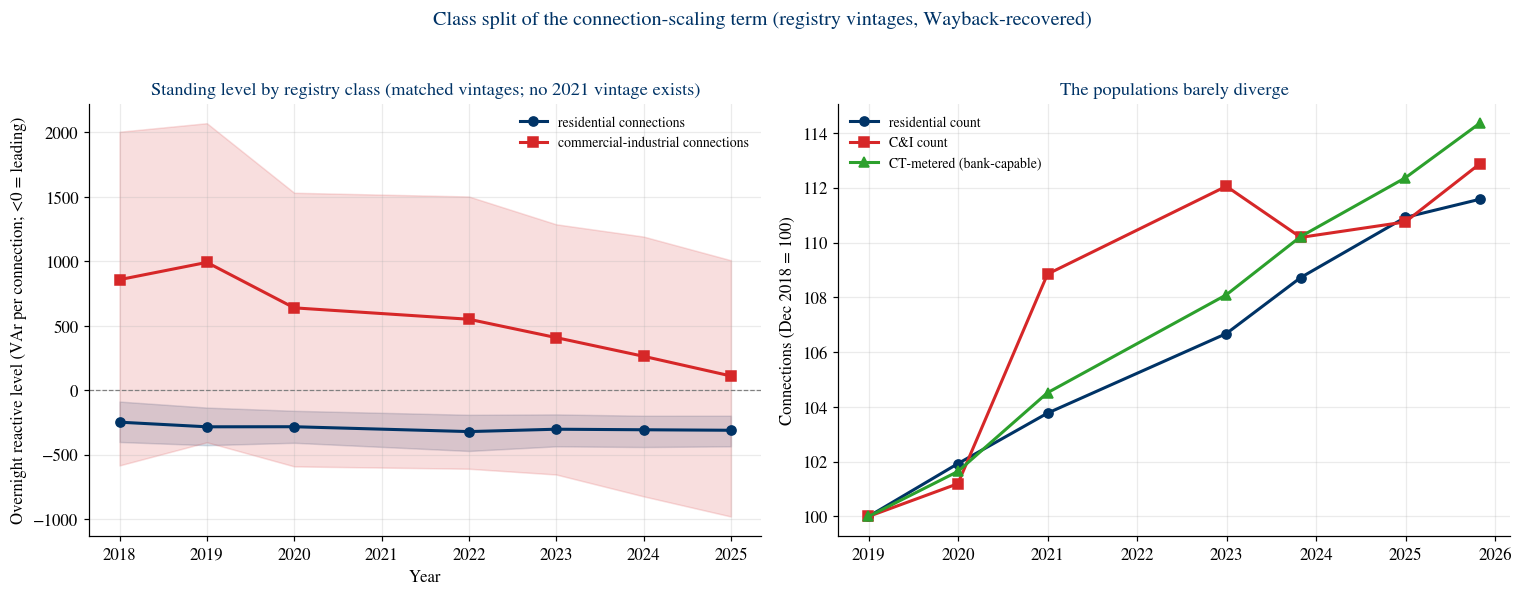

In [8]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.5))
yrs = list(hist)
axA.axhline(0, color="grey", lw=0.8, ls="--")
axA.plot(yrs, H.res, "-o", color=repro.EA_BLUE, lw=2, label="residential connections")
axA.fill_between(yrs, H.res_lo, H.res_hi, color=repro.EA_BLUE, alpha=0.15)
axA.plot(yrs, H.ci, "-s", color=repro.RED, lw=2, label="commercial-industrial connections")
axA.fill_between(yrs, H.ci_lo, H.ci_hi, color=repro.RED, alpha=0.15)
axA.set_xlabel("Year"); axA.set_ylabel("Overnight reactive level (VAr per connection; <0 = leading)")
axA.set_title("Standing level by registry class (matched vintages; no 2021 vintage exists)")
axA.legend(fontsize=9)
ye = [v for v in YEARENDS if v != "20260731"]
xd = pd.to_datetime(ye, format="%Y%m%d")
axB.plot(xd, mixseries.loc[ye, "res"] / mixseries.loc["20181231", "res"] * 100,
         "-o", color=repro.EA_BLUE, lw=2, label="residential count")
axB.plot(xd, mixseries.loc[ye, "ci"] / mixseries.loc["20181231", "ci"] * 100,
         "-s", color=repro.RED, lw=2, label="C&I count")
axB.plot(xd, (mixseries.loc[ye, "cat2"] + mixseries.loc[ye, "cat345"])
         / (mixseries.loc["20181231", "cat2"] + mixseries.loc["20181231", "cat345"]) * 100,
         "-^", color=repro.GREEN, lw=2, label="CT-metered (bank-capable)")
axB.set_ylabel("Connections (Dec 2018 = 100)"); axB.set_title("The populations barely diverge")
axB.legend(fontsize=9)
fig.suptitle("Class split of the connection-scaling term (registry vintages, Wayback-recovered)",
             color=repro.EA_BLUE)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(repro.FIGURES / "07_class_split.png")
plt.show()

### The journal-tier figure, emitted as TikZ

The journal tier gets the same result as vector TikZ rather than a raster: it sets
the two class coefficients beside the pooled coefficient they decompose. ⚠ It does
NOT draw the bottom-up per-household band: that band is a standing *level* and these
three coefficients are twelve-year *changes*, so plotting them against it stated a
comparison the paper's own Section V-C disowns (external review 2, 24 Aug 2026).
Drawing it as TikZ rather than a
PNG has three advantages beyond resolution — it takes the document's own fonts, its
printed values are visible to the paper's numeric-diff guard instead of being hidden
inside an image, and the coordinates are generated here, so the figure cannot drift
from the fit.

The pooled row is taken from the ICP regression's own results file, which is
canonical for that fit; the class rows come from the split above.

In [9]:
icp_res = json.load(open(REG / "icp_regression_results_20260806.json"))
pooled = icp_res["cluster_inference_20260810"]["slope_var_per_icp"]
share_ci = float(mixseries.loc["20260731", "s_ci"])

ROWS = [  # label, sub-label, point, [lo,hi] units, [lo,hi] companies, colour
    ("all connections", "the fitted slope", -pooled["point"],
     [-pooled["iid_pairs_boot"][1], -pooled["iid_pairs_boot"][0]],
     [-pooled["company_cluster_boot"][1], -pooled["company_cluster_boot"][0]], "clsall"),
    ("residential", f"{1 - share_ci:.0%} of connections".replace("%", r"\%"), -b[1] * 1e6,
     [-cu[1, 1] * 1e6, -cu[0, 1] * 1e6], [-cc[1, 1] * 1e6, -cc[0, 1] * 1e6], "clsres"),
    ("commercial and industrial", f"{share_ci:.0%} of connections".replace("%", r"\%"), -b[2] * 1e6,
     [-cu[1, 2] * 1e6, -cu[0, 2] * 1e6], [-cc[1, 2] * 1e6, -cc[0, 2] * 1e6], "clsci"),
]
VMIN, VMAX, W, DY = -1500.0, 60.0, 53.0, 8.0

def X(v):
    return (v - VMIN) * W / (VMAX - VMIN)

NL = chr(10)
L = ["% GENERATED by replication/src/07_anzsic_class_split.py -- do not edit by hand",
     r"\definecolor{clsall}{HTML}{4D4D4D}",
     r"\definecolor{clsres}{HTML}{003366}",
     r"\definecolor{clsci}{HTML}{D62728}",
     r"\begin{tikzpicture}[x=1mm,y=1mm,font=\scriptsize,line width=0.5pt]"]
ytop = (len(ROWS) - 1) * DY
L.append(f"\\draw[black!45,line width=0.4pt] ({X(0):.2f},-3.2) -- ({X(0):.2f},{ytop + 2.2:.2f});")
L.append(f"\\draw[black!55,line width=0.4pt] (0,-3.2) -- ({W:.2f},-3.2);")
for tick in (-1500, -1000, -500, 0):
    L.append(f"\\draw[black!55,line width=0.4pt] ({X(tick):.2f},-3.2) -- ({X(tick):.2f},-4.2);")
    L.append(f"\\node[below,font=\\tiny,text=black!70] at ({X(tick):.2f},-4.2) {{{tick}}};")
L.append(f"\\node[below,font=\\tiny,text=black!70,align=center] at ({W / 2:.2f},-7.4)"
         r" {VAr per connection\\(negative = added leading)};")
for i, (lab, sub, pt, ciu, cic, col) in enumerate(ROWS):
    y = (len(ROWS) - 1 - i) * DY
    L.append(f"\\draw[{col}!60,line width=0.8pt] ({X(cic[0]):.2f},{y:.2f}) -- ({X(cic[1]):.2f},{y:.2f});")
    L.append(f"\\draw[{col},line width=2.4pt] ({X(ciu[0]):.2f},{y:.2f}) -- ({X(ciu[1]):.2f},{y:.2f});")
    L.append(f"\\fill[white] ({X(pt):.2f},{y:.2f}) circle (1.05);")
    L.append(f"\\draw[{col},line width=0.7pt] ({X(pt):.2f},{y:.2f}) circle (1.05);")
    L.append(f"\\node[left,align=right,font=\\scriptsize] at (-1.2,{y + 0.7:.2f}) {{{lab}}};")
    L.append(f"\\node[left,align=right,font=\\tiny,text=black!60] at (-1.2,{y - 1.9:.2f}) {{{sub}}};")
# In-figure key. The thick/thin distinction used to live in the caption; Dave's
# 22 Aug steer moved reading-the-chart into the chart, so the key is drawn here.
YK = -15.2   # clear of the two-line axis label, which hangs to about -12
L.append(f"\\draw[black!70,line width=2.4pt] ({W * 0.04:.2f},{YK:.2f}) -- ({W * 0.15:.2f},{YK:.2f});")
L.append(f"\\node[right,font=\\tiny,text=black!70] at ({W * 0.16:.2f},{YK:.2f})"
         r" {95\% CI, resampling units};")
L.append(f"\\draw[black!70,line width=0.8pt] ({W * 0.56:.2f},{YK:.2f}) -- ({W * 0.67:.2f},{YK:.2f});")
L.append(f"\\node[right,font=\\tiny,text=black!70] at ({W * 0.68:.2f},{YK:.2f})"
         r" {resampling companies};")
L.append(r"\end{tikzpicture}")
(repro.FIGURES / "07_class_split.tex").write_text(NL.join(L) + NL)
print(f"figures/07_class_split.tex written, {len(L)} lines")
print(f"rows: pooled {-pooled['point']:+.0f}, residential {-b[1] * 1e6:+.0f}, "
      f"commercial-industrial {-b[2] * 1e6:+.0f}")
frag = (repro.FIGURES / "07_class_split.tex").read_text()
assert frag.count("%") == frag.count(r"\%") + 1, \
    "unescaped % in the TikZ fragment would comment out the rest of its line"
assert len(frag) > 800

figures/07_class_split.tex written, 39 lines
rows: pooled -230, residential -147, commercial-industrial -915


## Verdict

- **The scaling law's residential share is measurement-grade.** The class whose
  connections cannot hold correction plant carries a coefficient clear of zero
  under every resampling scheme and vintage choice. **[V]**
- **Stranded C&I correction is bounded, three ways.** Its required magnitude
  (~2 kVAr per C&I connection) is excluded; its required geography (concentration
  in C&I-heavy units) is absent; its required growth (a growing bank-capable
  population) is absent. And the C&I class's standing level is still net lagging —
  a stranded-bank-dominated class would read leading. **[V for the bounds, I for
  the mechanism reading]**
- **Caveats that travel:** the split is collinear (r = 0.94) — quote bounds, never
  a sharp allocation; class-resolved history begins December 2018 (nothing earlier
  exists in any archive) and has no 2021 vintage; the March 2020 reclassification
  step (~15k connections) sits inside the C&I series; level coefficients absorb
  each class's share of network cable charging, so they are all-in standing
  positions, not device-only quantities.

In [10]:
out = {
    "change_split": {"res": float(b[1] * 1e6), "ci": float(b[2] * 1e6),
                     "res_ci_units": [float(cu[0, 1] * 1e6), float(cu[1, 1] * 1e6)],
                     "res_ci_companies": [float(cc[0, 1] * 1e6), float(cc[1, 1] * 1e6)],
                     "ci_ci_units": [float(cu[0, 2] * 1e6), float(cu[1, 2] * 1e6)],
                     "ci_ci_companies": [float(cc[0, 2] * 1e6), float(cc[1, 2] * 1e6)],
                     "collinearity": collin,
                     "sensitivities": {k: [float(a), float(bq)] for k, (a, bq) in sens.items()}},
    "level_history": {int(k): v for k, v in hist.items()},
    "growth": growth,
    "mix_band": [float(mixseries.s_ci.min()), float(mixseries.s_ci.max())],
    "vintages": VINTAGES,
}
with open(repro.CACHE / "anzsic_class_split.json", "w") as f:
    json.dump(out, f, indent=1)
print("cache/anzsic_class_split.json written — canonical values for the paper's Section V-C")

cache/anzsic_class_split.json written — canonical values for the paper's Section V-C
